# Steam Game Market Analytics

### Predicting and Explaining Metacritic Scores Using Steam Game Metadata

- This project analyzes Steam game metadata to understand which product features are associated with stronger critical reception, measured by Metacritic score.

- ***The original version of this project was completed as a university statistical modeling project. This notebook rebuilds the analysis into an industry-facing product analytics case study, focusing on data quality, exploratory analysis, predictive modeling, interpretation, and business recommendations.***

In [39]:
library(tidyverse)
library(lubridate)
library(broom)
library(glmnet)
library(caret)
library(leaps)
knitr::opts_chunk$set(message = FALSE, warning = FALSE)


In [40]:
options(jupyter.rich_display = FALSE)
options(repr.matrix.max.rows = 20)
options(repr.matrix.max.cols = 20)

theme_set(
  theme_minimal(base_size = 18) +
    theme(
      plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
      plot.subtitle = element_text(size = 14, hjust = 0.5),
      axis.title = element_text(size = 16),
      axis.text = element_text(size = 13),
      panel.grid.minor = element_blank()
    )
)



## 1. Business Context

Steam is one of the largest digital platforms for PC games. With thousands of games available, players, developers, publishers, and platform stakeholders often rely on review signals to evaluate game quality and market reception.

Metacritic scores are commonly used as a high-level indicator of critical reception. For game publishers and platform analysts, understanding which product features are associated with stronger review performance can support market research, pricing strategy, product positioning, and launch planning.

This project asks:

> **How much can structured Steam metadata tell us about a game's critical reception?**

## 2. Key Questions

### This analysis focuses on four key questions:

- Which Steam game attributes are associated with higher Metacritic scores?

- How do price, release timing, recommendation count, and genre categories relate to critical reception?

- Can structured Steam metadata predict Metacritic scores with reasonable accuracy?

- What are the limitations of using platform metadata to estimate review performance?

In [41]:
steam_raw <- read_csv("../data/raw/steam_games.csv")
head(steam_raw)

Rows: 12624 Columns: 19
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): ResponseName, ReleaseDate
dbl  (3): Metacritic, RecommendationCount, PriceInitial
lgl (14): IsFree, GenreIsNonGame, GenreIsIndie, GenreIsAction, GenreIsAdvent...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


  ResponseName              ReleaseDate Metacritic RecommendationCount IsFree
1 Counter-Strike            Nov 1 2000  88         68991               FALSE 
2 Team Fortress Classic     Apr 1 1999   0          2439               FALSE 
3 Day of Defeat             May 1 2003  79          2319               FALSE 
4 Deathmatch Classic        Jun 1 2001   0           888               FALSE 
5 Half-Life: Opposing Force Nov 1 1999   0          2934               FALSE 
6 Ricochet                  Nov 1 2000   0          1965               FALSE 
  GenreIsNonGame GenreIsIndie GenreIsAction GenreIsAdventure GenreIsCasual
1 FALSE          FALSE        TRUE          FALSE            FALSE        
2 FALSE          FALSE        TRUE          FALSE            FALSE        
3 FALSE          FALSE        TRUE          FALSE            FALSE        
4 FALSE          FALSE        TRUE          FALSE            FALSE        
5 FALSE          FALSE        TRUE          FALSE            FALSE        
6 FA

In [42]:
colnames(steam_raw)

 [1] "ResponseName"                "ReleaseDate"                
 [3] "Metacritic"                  "RecommendationCount"        
 [5] "IsFree"                      "GenreIsNonGame"             
 [7] "GenreIsIndie"                "GenreIsAction"              
 [9] "GenreIsAdventure"            "GenreIsCasual"              
[11] "GenreIsStrategy"             "GenreIsRPG"                 
[13] "GenreIsSimulation"           "GenreIsEarlyAccess"         
[15] "GenreIsFreeToPlay"           "GenreIsSports"              
[17] "GenreIsRacing"               "GenreIsMassivelyMultiplayer"
[19] "PriceInitial"               

## 3. Data Overview

The dataset contains Steam game metadata, including game title, release date, Metacritic score, Steam recommendation count, price, free-to-play status, and genre indicators.

The target variable is `Metacritic`, a critic score ranging from 0 to 100. In this dataset, many games have a Metacritic value of 0, which likely indicates that no Metacritic score was available rather than an actual score of zero.

In [43]:
steam_raw %>%
  summarise(
    rows = n(),
    columns = ncol(steam_raw),
    metacritic_zero_count = sum(Metacritic == 0, na.rm = TRUE),
    metacritic_positive_count = sum(Metacritic > 0, na.rm = TRUE),
    metacritic_na_count = sum(is.na(Metacritic))
  )


  rows  columns metacritic_zero_count metacritic_positive_count
1 12624 19      10357                 2267                     
  metacritic_na_count
1 0                  

In [44]:
missing_summary <- steam_raw %>%
  summarise(across(everything(), ~ sum(is.na(.)))) %>%
  pivot_longer(
    cols = everything(),
    names_to = "column",
    values_to = "missing_count"
  ) %>%
  arrange(desc(missing_count))

missing_summary


   column                      missing_count
1  ReleaseDate                 86           
2  ResponseName                 0           
3  Metacritic                   0           
4  RecommendationCount          0           
5  IsFree                       0           
6  GenreIsNonGame               0           
7  GenreIsIndie                 0           
8  GenreIsAction                0           
9  GenreIsAdventure             0           
10 GenreIsCasual                0           
11 GenreIsStrategy              0           
12 GenreIsRPG                   0           
13 GenreIsSimulation            0           
14 GenreIsEarlyAccess           0           
15 GenreIsFreeToPlay            0           
16 GenreIsSports                0           
17 GenreIsRacing                0           
18 GenreIsMassivelyMultiplayer  0           
19 PriceInitial                 0           

- The most important data quality issue is the large number of games with `Metacritic = 0`. Since Metacritic scores are normally reported on a 0–100 scale and true zero scores are unrealistic, these values are treated as unavailable scores and excluded from the modeling dataset.

## 4. Data Cleaning

- The dataset contains 12,624 Steam games, but only 2,267 games have a positive Metacritic score. Since `Metacritic = 0` likely represents unavailable critic scores rather than actual review outcomes, the modeling dataset is restricted to games with `Metacritic > 0`.

- Release dates are also converted into a parsed date field and release year, which can be used as a time-based feature in later analysis.

In [45]:
steam_clean <- steam_raw %>%
  filter(Metacritic > 0) %>%  ## Remove games with Metacritic score of 0 (likely missing or unrated)
  mutate(
    ReleaseDateParsed = mdy(ReleaseDate),  ### Parse ReleaseDate to Date format
    ReleaseYear = year(ReleaseDateParsed),
    IsFree = as.logical(IsFree), 
    across(starts_with("Genre"), as.logical) 
  ) %>%
  filter(!is.na(ReleaseDateParsed))

steam_clean %>%
  summarise(
    cleaned_rows = n(),
    min_metacritic = min(Metacritic, na.rm = TRUE),
    max_metacritic = max(Metacritic, na.rm = TRUE),
    mean_metacritic = round(mean(Metacritic, na.rm = TRUE), 2),
    median_metacritic = median(Metacritic, na.rm = TRUE),
    min_release_year = min(ReleaseYear, na.rm = TRUE),
    max_release_year = max(ReleaseYear, na.rm = TRUE)
  ) %>%
  print()

# A tibble: 1 × 7
  cleaned_rows min_metacritic max_metacritic mean_metacritic median_metacritic
         <int>          <dbl>          <dbl>           <dbl>             <dbl>
1         2255             20             96            72.2                74
# ℹ 2 more variables: min_release_year <dbl>, max_release_year <dbl>


In [46]:
write_csv(steam_clean, "../data/processed/steam_games_clean.csv")

## 5. Exploratory Data Analysis

##### Before building regression models, this section explores the distribution of Metacritic scores and how key product features such as price, recommendation count, release year, and genre categories relate to critical reception.

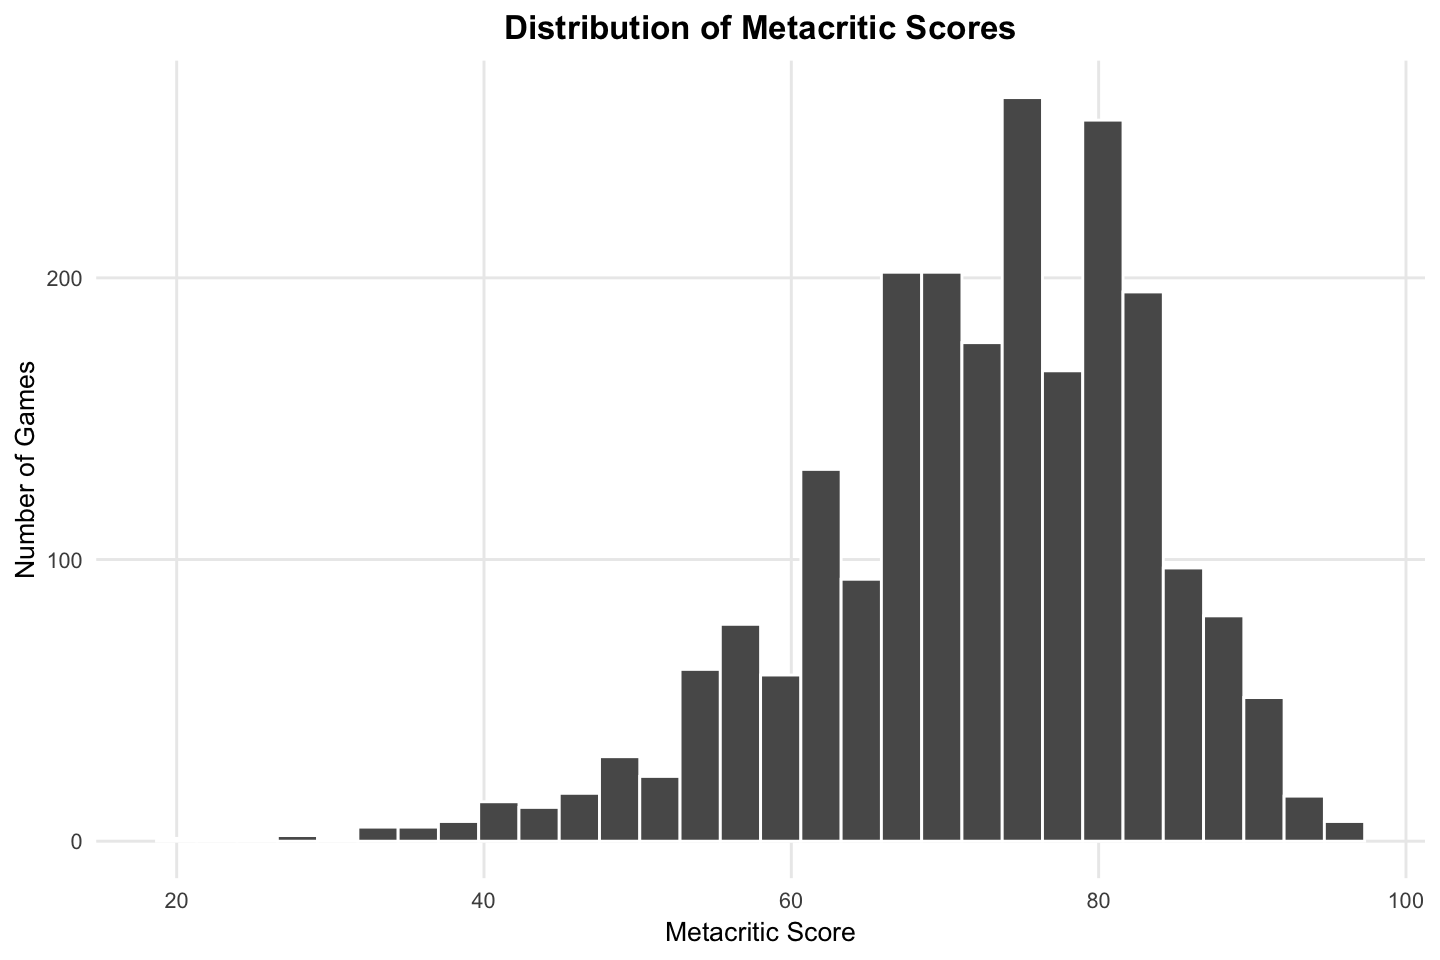

In [47]:
## 1. Distribution of Metacritic scores

ggplot(steam_clean, aes(x = Metacritic)) +
  geom_histogram(bins = 30, color = "white") +
  labs(
    title = "Distribution of Metacritic Scores",
    x = "Metacritic Score",
    y = "Number of Games"
  ) 

Most games with available Metacritic scores are concentrated between 65 and 85, with a peak around the mid-to-high 70s. This suggests that the scored subset is skewed toward games with moderate to positive critical reception, while very low-scoring games are relatively uncommon.

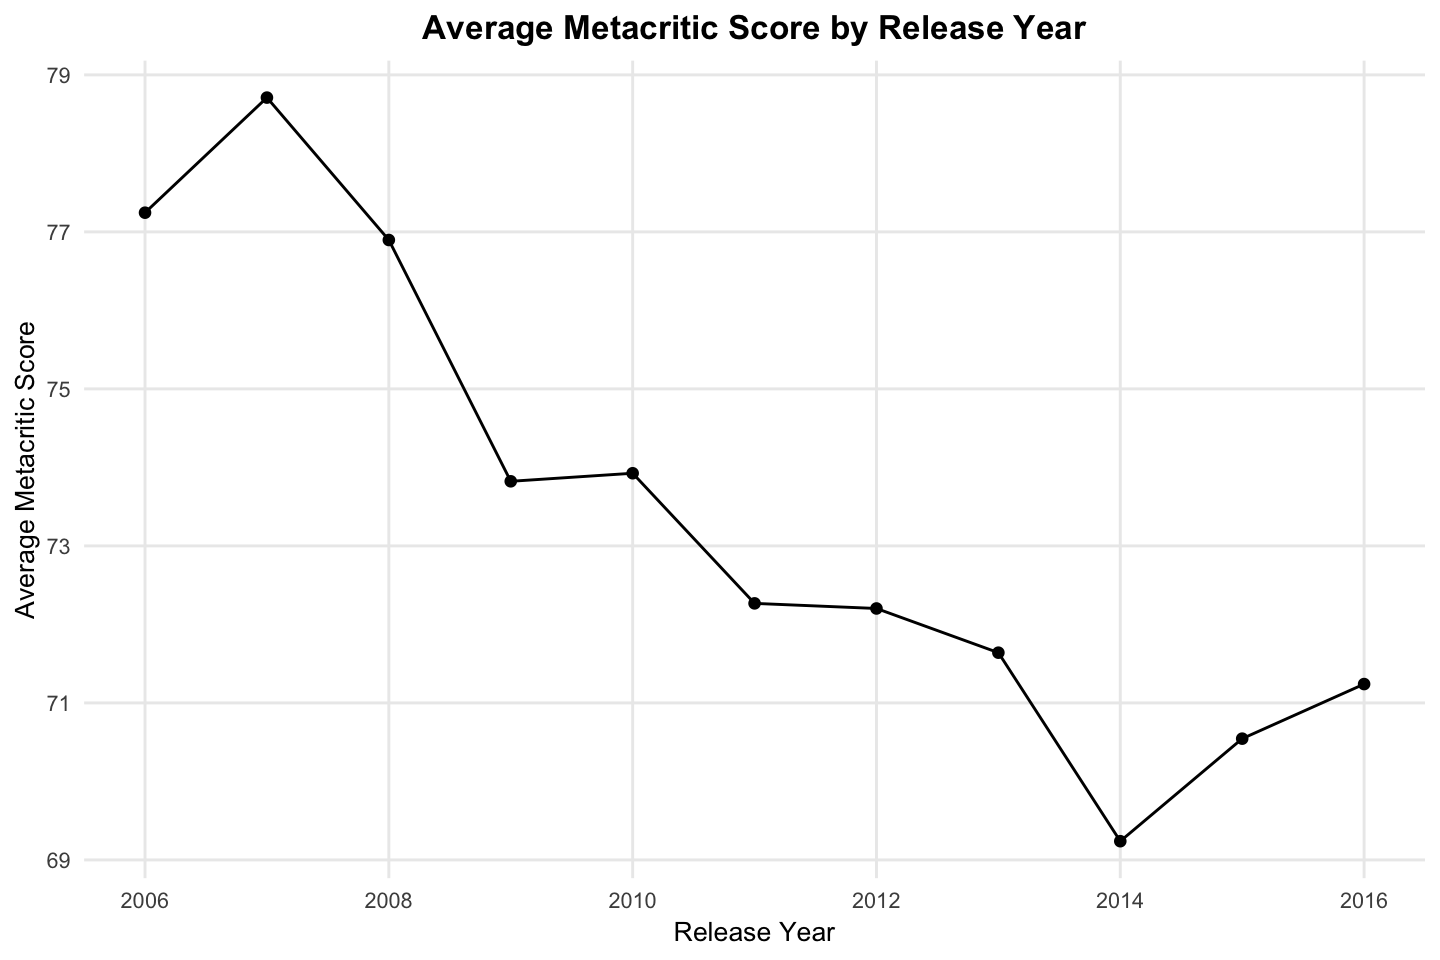

In [48]:
## 2.Release Year vs Metacritic

steam_clean %>%
  group_by(ReleaseYear) %>%
  summarise(
    avg_metacritic = mean(Metacritic, na.rm = TRUE),
    game_count = n()
  ) %>%
  filter(game_count >= 10) %>% ## Only include years with at least 10 games for reliability, 
                               ## because some years have very few games which can skew the average
ggplot(aes(x = ReleaseYear, y = avg_metacritic)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Average Metacritic Score by Release Year",
    x = "Release Year",
    y = "Average Metacritic Score"
  ) 

In [49]:
steam_clean %>%
  group_by(ReleaseYear) %>%
  summarise(
    avg_metacritic = round(mean(Metacritic), 2),
    game_count = n()
  ) %>%
  arrange(ReleaseYear) %>%
  print()

# A tibble: 17 × 3
   ReleaseYear avg_metacritic game_count
         <dbl>          <dbl>      <int>
 1        1998           96            1
 2        2000           88            1
 3        2001           76            2
 4        2003           79            1
 5        2004           78.7          6
 6        2005           80.2          4
 7        2006           77.2         45
 8        2007           78.7         76
 9        2008           76.9        116
10        2009           73.8        192
11        2010           73.9        161
12        2011           72.3        194
13        2012           72.2        207
14        2013           71.6        261
15        2014           69.2        369
16        2015           70.5        369
17        2016           71.2        250


`geom_smooth()` using formula = 'y ~ x'


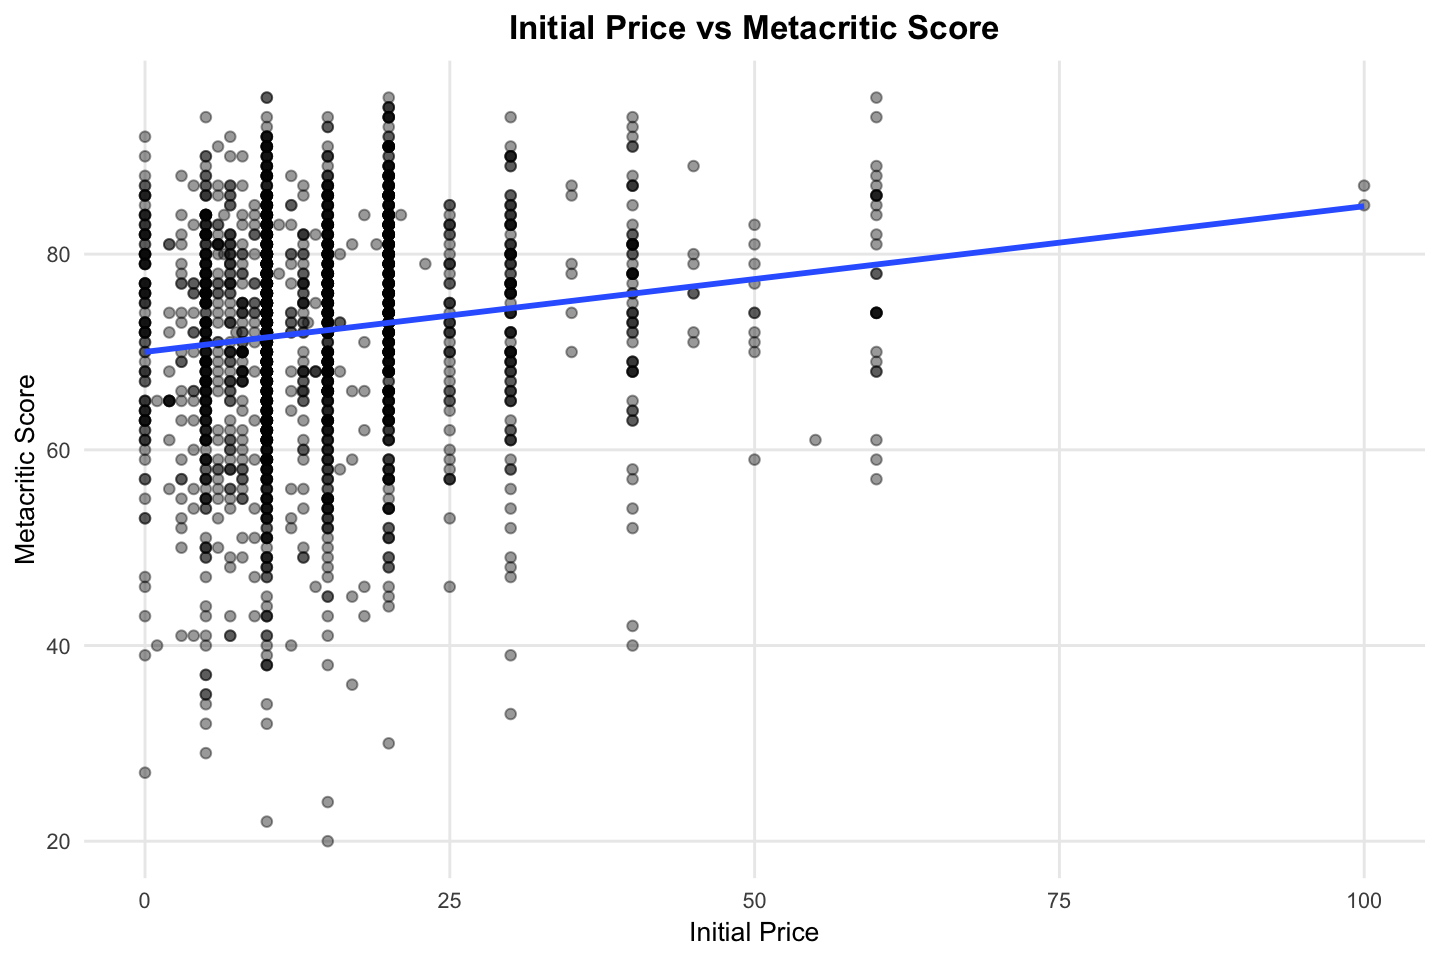

In [50]:
## Initial Price vs Metacritic

options(repr.plot.width = 12)
options(repr.plot.height = 8)
steam_clean %>%
  filter(PriceInitial <= 100) %>% ## Filter out extreme outliers for better visualization
  ggplot(aes(x = PriceInitial, y = Metacritic)) +
  geom_point(alpha = 0.4) +
  geom_smooth(method = "lm", se = FALSE) + ## Add linear regression line to show overall trend
  labs(
    title = "Initial Price vs Metacritic Score",
    x = "Initial Price",
    y = "Metacritic Score"
  ) 

- Initial price shows a weak positive relationship with Metacritic score, but the points are widely dispersed. This suggests that price may contain some product-positioning signal, but it is unlikely to explain critical reception on its own.

`geom_smooth()` using formula = 'y ~ x'


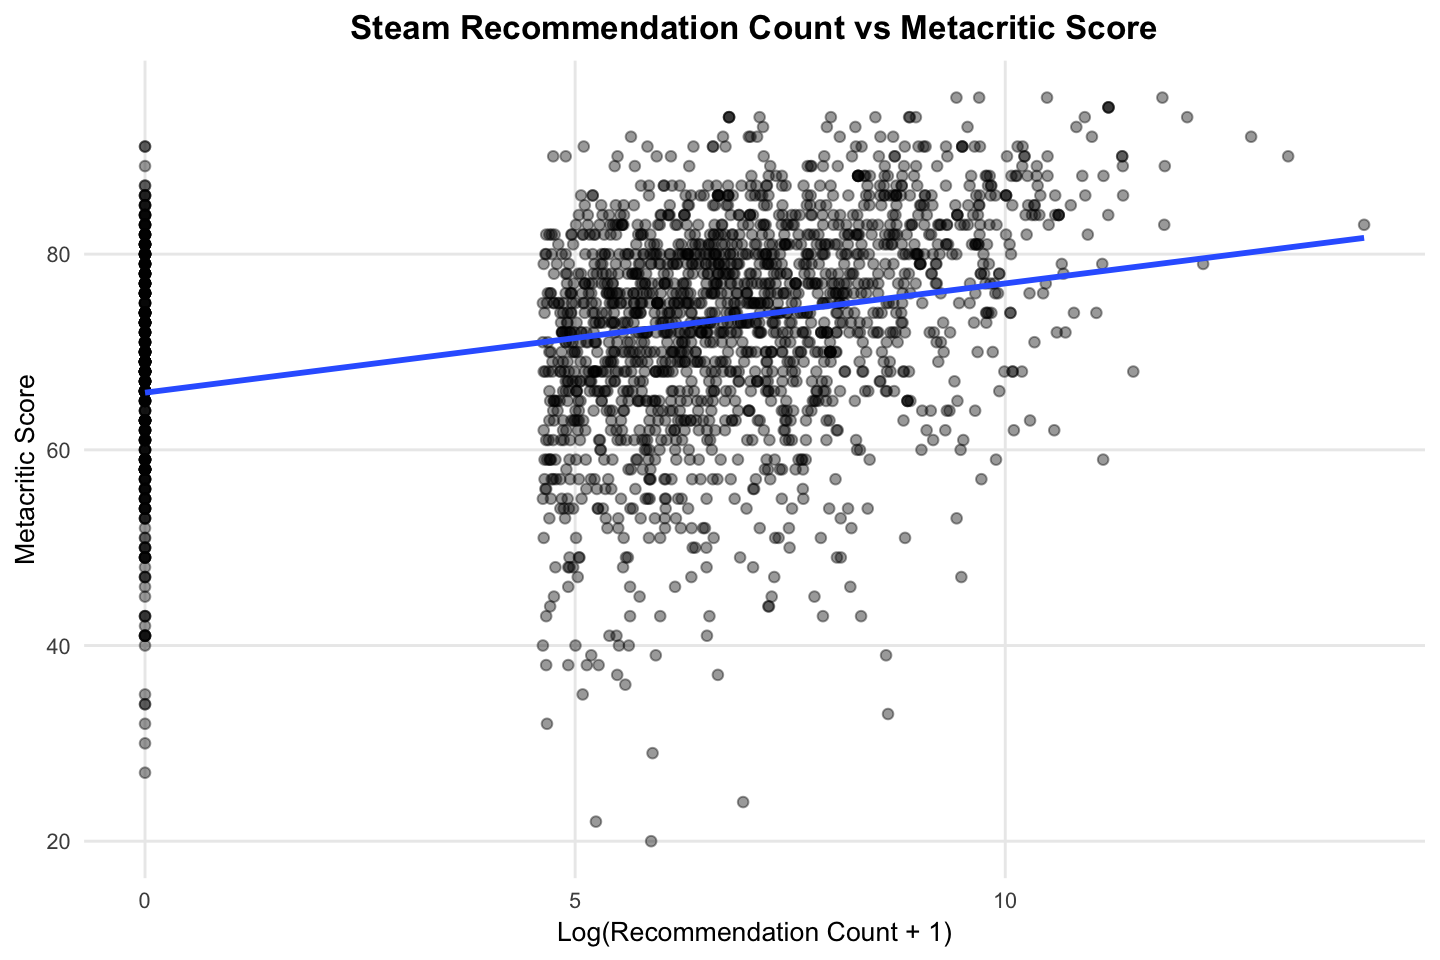

In [51]:
## 4. RecommendationCount vs Metacritic Score

options(repr.plot.width = 12)
options(repr.plot.height = 8)

steam_clean %>%
  mutate(LogRecommendationCount = log1p(RecommendationCount)) %>% ## Log-transform RecommendationCount to handle skewness and zero values
  ggplot(aes(x = LogRecommendationCount, y = Metacritic)) +
  geom_point(alpha = 0.4) +
  geom_smooth(method = "lm", se = FALSE) +
  labs(
    title = "Steam Recommendation Count vs Metacritic Score",
    x = "Log(Recommendation Count + 1)",
    y = "Metacritic Score"
  ) 

- After applying a log transformation to recommendation count, the relationship with Metacritic score appears moderately positive. Games with more Steam recommendations tend to have higher critic scores, although substantial variation remains.

In [52]:
genre_summary <- steam_clean %>%
  select(Metacritic, starts_with("Genre")) %>%
  pivot_longer(
    cols = starts_with("Genre"),
    names_to = "genre",
    values_to = "is_genre" 
  ) %>%
  filter(is_genre == TRUE) %>%
  mutate(
    genre_label = str_remove(genre, "GenreIs"), ## Remove "GenreIs" prefix for cleaner labels
    genre_label = str_replace_all(genre_label, "([a-z])([A-Z])", "\\1 \\2")
  ) %>%
  group_by(genre_label) %>%
  summarise(
    avg_metacritic = round(mean(Metacritic, na.rm = TRUE), 2),
    game_count = n(),
    .groups = "drop"
  ) %>%
  filter(game_count >= 20) %>%
  arrange(desc(avg_metacritic))

genre_summary %>%
  print()

# A tibble: 11 × 3
   genre_label           avg_metacritic game_count
   <chr>                          <dbl>      <int>
 1 Sports                          74.6         62
 2 Massively Multiplayer           74.3         50
 3 RPG                             73.4        404
 4 Racing                          72.6         90
 5 Free To Play                    72.4         64
 6 Strategy                        72.2        603
 7 Action                          71.6       1116
 8 Casual                          71.4        213
 9 Adventure                       71.4        744
10 Indie                           70.9       1008
11 Simulation                      70.6        262


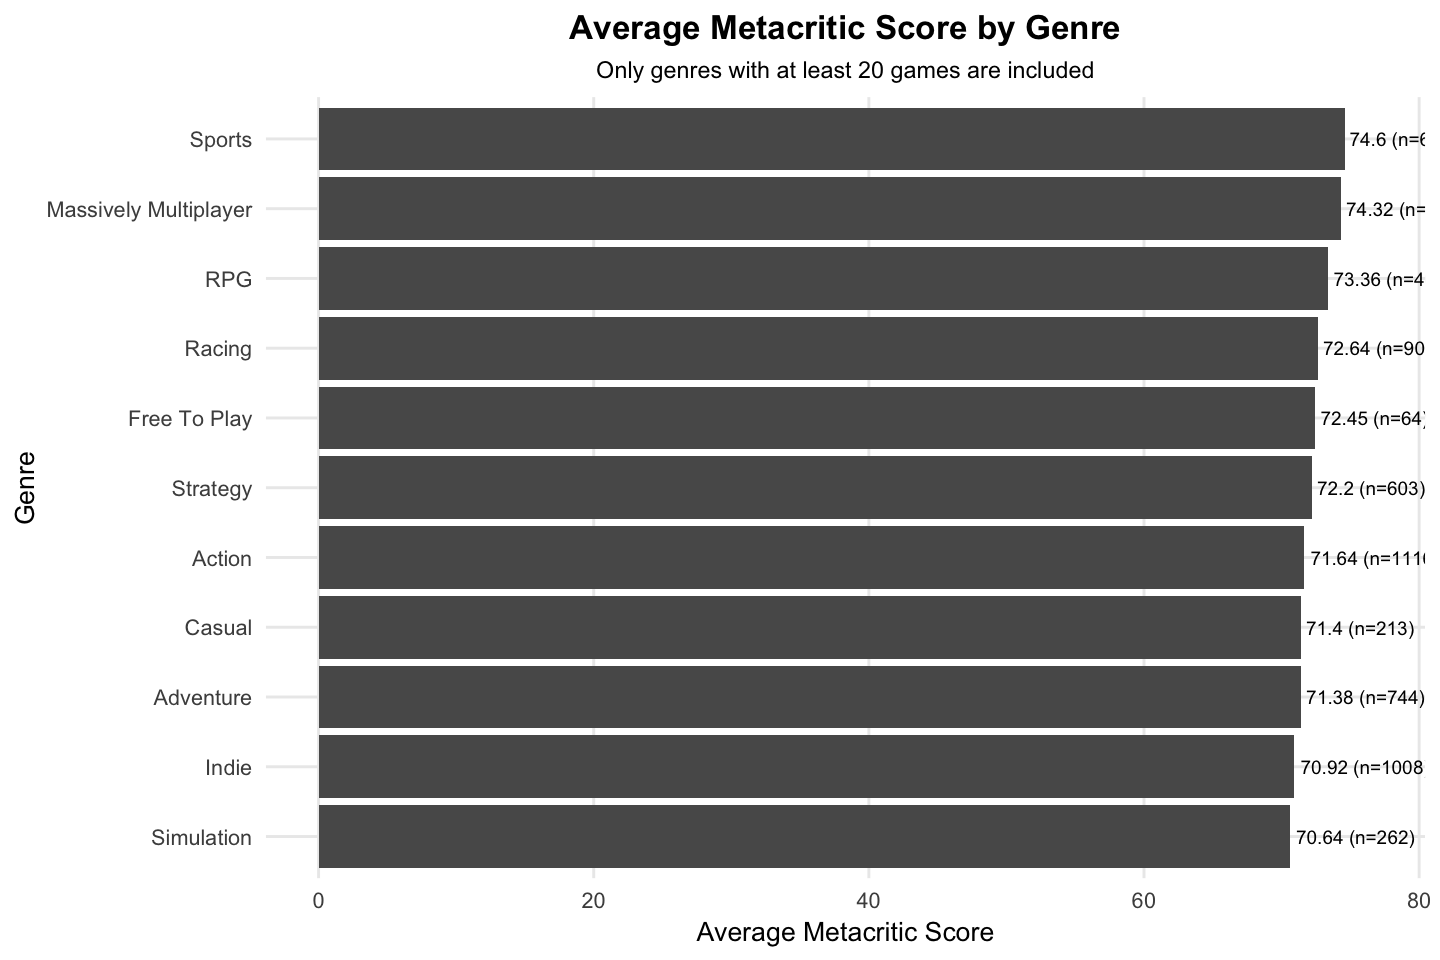

In [53]:
## 5. Average Metacritic Score by Genre

ggplot(
  genre_summary,
  aes(x = reorder(genre_label, avg_metacritic), y = avg_metacritic)
) +
  geom_col() +
  geom_text(
    aes(label = paste0(avg_metacritic, " (n=", game_count, ")")),
    hjust = -0.05,
    size = 4
  ) +
  coord_flip() +
  expand_limits(y = max(genre_summary$avg_metacritic) + 2) +
  labs(
    title = "Average Metacritic Score by Genre",
    subtitle = "Only genres with at least 20 games are included",
    x = "Genre",
    y = "Average Metacritic Score"
  )

- Genre-level averages show modest variation in Metacritic scores. Sports, Massively Multiplayer, and RPG games have the highest average Metacritic scores among genres with at least 20 games, while Indie and Simulation games have lower averages in this dataset.

- However, the differences are relatively narrow, with most genre averages falling between 71 and 75. These comparisons should be interpreted cautiously because games can belong to multiple genres, and smaller genre groups may have more unstable averages. This descriptive analysis motivates the use of regression models to evaluate genre effects while controlling for other features such as price, release year, and recommendation count.

## 6. Modeling Approach

#### The goal of the modeling section is to evaluate how well structured Steam game metadata can predict Metacritic scores.

This project follows the original UBC STAT 301 modeling direction by comparing multiple regression-based approaches:

**1. Full multiple linear regression**

**2. Forward-selected reduced linear regression**

**3. LASSO regression**

Model performance will be evaluated using RMSE on a held-out test set. Since the target variable is numerical, RMSE provides an interpretable measure of average prediction error in Metacritic score points.

## 7. Train-Test Split

The cleaned dataset is split into training and test sets. The training set is used to fit the models, while the test set is held out for model evaluation.

In [54]:
set.seed(301)

train_index <- createDataPartition(
  steam_clean$Metacritic,
  p = 0.8,
  list = FALSE
)

train_data <- steam_clean[train_index, ]
test_data <- steam_clean[-train_index, ]

nrow(train_data)
nrow(test_data)

[1] 1805

[1] 450

## 8. Full Multiple Linear Regression

The first model is a full multiple linear regression model using price, recommendation count, release year, free-to-play status, and genre indicators as predictors.

In [55]:
full_lm <- lm(
  Metacritic ~ 
    PriceInitial +
    log1p(RecommendationCount) +
    ReleaseYear +
    IsFree +
    GenreIsIndie +
    GenreIsAction +
    GenreIsAdventure +
    GenreIsCasual +
    GenreIsStrategy +
    GenreIsRPG +
    GenreIsSimulation +
    GenreIsEarlyAccess +
    GenreIsFreeToPlay +
    GenreIsSports +
    GenreIsRacing +
    GenreIsMassivelyMultiplayer,
  data = train_data
)

summary(full_lm)


Call:
lm(formula = Metacritic ~ PriceInitial + log1p(RecommendationCount) + 
    ReleaseYear + IsFree + GenreIsIndie + GenreIsAction + GenreIsAdventure + 
    GenreIsCasual + GenreIsStrategy + GenreIsRPG + GenreIsSimulation + 
    GenreIsEarlyAccess + GenreIsFreeToPlay + GenreIsSports + 
    GenreIsRacing + GenreIsMassivelyMultiplayer, data = train_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-50.548  -5.785   1.471   7.206  29.316 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                     1591.02837  211.10121   7.537 7.61e-14 ***
PriceInitial                       0.08383    0.02195   3.818 0.000139 ***
log1p(RecommendationCount)         1.05931    0.08616  12.295  < 2e-16 ***
ReleaseYear                       -0.75766    0.10501  -7.215 7.91e-13 ***
IsFreeTRUE                        -0.88264    2.37859  -0.371 0.710625    
GenreIsIndieTRUE                  -0.43603    0.57538  -0.758 0.448666    
GenreIsA

## Model 1: Full Model Test Performance

To evaluate predictive performance, the full linear regression model is tested on the held-out test set using RMSE. RMSE measures the average prediction error in Metacritic score points.

In [56]:
rmse <- function(actual, predicted) {
  sqrt(mean((actual - predicted)^2, na.rm = TRUE))
}

full_pred <- predict(full_lm, newdata = test_data)

full_rmse <- rmse(test_data$Metacritic, full_pred)

full_rmse

[1] 9.68895

## Model 2: Forward Selection

Forward selection starts with no predictors and adds variables step by step based on model fit. The goal is to identify a smaller regression model that keeps the most useful predictors while reducing unnecessary complexity.

In [57]:
forward_model <- regsubsets(
  Metacritic ~ 
    PriceInitial +
    log1p(RecommendationCount) +
    ReleaseYear +
    IsFree +
    GenreIsIndie +
    GenreIsAction +
    GenreIsAdventure +
    GenreIsCasual +
    GenreIsStrategy +
    GenreIsRPG +
    GenreIsSimulation +
    GenreIsEarlyAccess +
    GenreIsFreeToPlay +
    GenreIsSports +
    GenreIsRacing +
    GenreIsMassivelyMultiplayer,
  data = train_data,
  nvmax = 16,
  method = "forward"
)

forward_summary <- summary(forward_model)

which.min(forward_summary$bic)

[1] 4

In [58]:
forward_summary <- summary(forward_model)

# Display the variable selection matrix
forward_summary

Subset selection object
Call: regsubsets.formula(Metacritic ~ PriceInitial + log1p(RecommendationCount) + 
    ReleaseYear + IsFree + GenreIsIndie + GenreIsAction + GenreIsAdventure + 
    GenreIsCasual + GenreIsStrategy + GenreIsRPG + GenreIsSimulation + 
    GenreIsEarlyAccess + GenreIsFreeToPlay + GenreIsSports + 
    GenreIsRacing + GenreIsMassivelyMultiplayer, data = train_data, 
    nvmax = 16, method = "forward")
16 Variables  (and intercept)
                                Forced in Forced out
PriceInitial                        FALSE      FALSE
log1p(RecommendationCount)          FALSE      FALSE
ReleaseYear                         FALSE      FALSE
IsFreeTRUE                          FALSE      FALSE
GenreIsIndieTRUE                    FALSE      FALSE
GenreIsActionTRUE                   FALSE      FALSE
GenreIsAdventureTRUE                FALSE      FALSE
GenreIsCasualTRUE                   FALSE      FALSE
GenreIsStrategyTRUE                 FALSE      FALSE
GenreIsRPGTRUE  

In [59]:
coef(forward_model, id = which.min(forward_summary$bic))

               (Intercept)               PriceInitial 
             1661.42348970                 0.08685944 
log1p(RecommendationCount)                ReleaseYear 
                1.05402499                -0.79279764 
         GenreIsActionTRUE 
               -2.49166905 

### Reduced Linear Regression Model

Based on BIC from forward selection, the reduced model keeps four predictors: **initial price, log-transformed recommendation count, release year, and whether the game is tagged as Action**.

This model is simpler than the full model while retaining the strongest predictive signals identified during model selection.

In [60]:
reduced_lm <- lm(
  Metacritic ~
    PriceInitial +
    log1p(RecommendationCount) +
    ReleaseYear +
    GenreIsAction,
  data = train_data
)

summary(reduced_lm)


Call:
lm(formula = Metacritic ~ PriceInitial + log1p(RecommendationCount) + 
    ReleaseYear + GenreIsAction, data = train_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-50.533  -5.791   1.345   7.469  29.480 

Coefficients:
                             Estimate Std. Error t value Pr(>|t|)    
(Intercept)                1661.42349  179.60488   9.250  < 2e-16 ***
PriceInitial                  0.08686    0.02058   4.220 2.57e-05 ***
log1p(RecommendationCount)    1.05402    0.08330  12.653  < 2e-16 ***
ReleaseYear                  -0.79280    0.08925  -8.883  < 2e-16 ***
GenreIsActionTRUE            -2.49167    0.50287  -4.955 7.92e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 10.49 on 1800 degrees of freedom
Multiple R-squared:  0.1456,	Adjusted R-squared:  0.1437 
F-statistic: 76.67 on 4 and 1800 DF,  p-value: < 2.2e-16


In [61]:
reduced_pred <- predict(reduced_lm, newdata = test_data)

reduced_rmse <- rmse(test_data$Metacritic, reduced_pred)

reduced_rmse

[1] 9.676103

- The forward-selected reduced model keeps four predictors: **initial price, log-transformed recommendation count, release year, and Action genre**.

- Compared with the full model, the reduced model has a **slightly lower** test RMSE while using far fewer predictors. This suggests that many genre indicators in the full model add **limited** predictive value. The reduced model provides a **simpler and more interpretable** alternative without sacrificing predictive performance.

- The model still has **limited** explanatory power, with an adjusted R-squared of about 0.139. This suggests that structured Steam metadata captures some signal, but most **variation** in Metacritic scores is likely driven by factors **not** included in the dataset, such as **gameplay quality, studio reputation, technical performance, marketing, and critic expectations**.

### LASSO Regression

LASSO regression adds an L1 penalty to the regression model. This penalty can shrink some coefficients exactly to zero, making LASSO useful for variable selection and reducing model complexity.

This project uses cross-validated LASSO to compare a regularized regression approach against the full and forward-selected linear regression models.

In [62]:
## Train Lasso Regression
x_train <- model.matrix(
  Metacritic ~ 
    PriceInitial +
    log1p(RecommendationCount) +
    ReleaseYear +
    IsFree +
    GenreIsIndie +
    GenreIsAction +
    GenreIsAdventure +
    GenreIsCasual +
    GenreIsStrategy +
    GenreIsRPG +
    GenreIsSimulation +
    GenreIsEarlyAccess +
    GenreIsFreeToPlay +
    GenreIsSports +
    GenreIsRacing +
    GenreIsMassivelyMultiplayer,
  data = train_data
)[, -1]

y_train <- train_data$Metacritic

## Test Lasso Regression
x_test <- model.matrix(
  Metacritic ~ 
    PriceInitial +
    log1p(RecommendationCount) +
    ReleaseYear +
    IsFree +
    GenreIsIndie +
    GenreIsAction +
    GenreIsAdventure +
    GenreIsCasual +
    GenreIsStrategy +
    GenreIsRPG +
    GenreIsSimulation +
    GenreIsEarlyAccess +
    GenreIsFreeToPlay +
    GenreIsSports +
    GenreIsRacing +
    GenreIsMassivelyMultiplayer,
  data = test_data
)[, -1]

set.seed(123)

## Use cross-validation to find optimal lambda for Lasso
lasso_cv <- cv.glmnet(
  x = x_train,
  y = y_train,
  alpha = 1
)

lasso_pred <- predict(lasso_cv, newx = x_test, s = "lambda.min")

lasso_rmse <- rmse(test_data$Metacritic, lasso_pred)

lasso_rmse

[1] 9.653534

In [63]:
model_comparison <- tibble(
  model = c(
    "Full Multiple Linear Regression",
    "Forward-Selected Reduced Regression",
    "LASSO Regression"
  ),
  test_rmse = c(
    full_rmse,
    reduced_rmse,
    as.numeric(lasso_rmse)
  )
) %>%
  arrange(test_rmse)

model_comparison

  model                               test_rmse
1 LASSO Regression                    9.653534 
2 Forward-Selected Reduced Regression 9.676103 
3 Full Multiple Linear Regression     9.688950 

### Model Comparison

- The LASSO regression model achieved the lowest test RMSE, although the difference between LASSO, forward selection, and the reduced linear regression model is very small. This suggests that the full model does not provide a meaningful predictive advantage over simpler or regularized alternatives.

- Although the LASSO regression model also performs well and produces a test RMSE very close to the forward-selected model, the forward-selected reduced model is **preferred** because it has the lowest test RMSE and uses a smaller, more interpretable set of predictors. 

- The full multiple linear regression model has the **highest test RMSE**, suggesting that adding more predictors does not necessarily improve prediction performance.

- The final selected predictors are initial price, log-transformed recommendation count, release year, and Action genre. Overall, RMSE values around 9.6 Metacritic points suggest that structured Steam metadata can provide rough directional predictions, but it is **not accurate** enough to precisely forecast critic scores.

In [64]:
coef(lasso_cv, s = "lambda.min")

17 x 1 sparse Matrix of class "dgCMatrix"
                                   lambda.min
(Intercept)                     1493.84668702
PriceInitial                       0.07437957
log1p(RecommendationCount)         0.99151004
ReleaseYear                       -0.70929483
IsFreeTRUE                        -0.21903555
GenreIsIndieTRUE                  -0.14423258
GenreIsActionTRUE                 -2.17480181
GenreIsAdventureTRUE               .         
GenreIsCasualTRUE                  .         
GenreIsStrategyTRUE                .         
GenreIsRPGTRUE                     0.37704355
GenreIsSimulationTRUE             -1.35995416
GenreIsEarlyAccessTRUE             6.40483388
GenreIsFreeToPlayTRUE              .         
GenreIsSportsTRUE                  1.64548964
GenreIsRacingTRUE                  .         
GenreIsMassivelyMultiplayerTRUE    1.83035989

- The LASSO model produced a test RMSE very close to the forward-selected reduced regression model. This suggests that regularization **did not** substantially improve predictive performance in this dataset.

- However, LASSO still provides useful confirmation. It retained the main predictors identified by the reduced regression model, including initial price, log-transformed recommendation count, release year, and Action genre. Several genre indicators were shrunk to zero, suggesting that not all genre categories contributed meaningful predictive signal after regularization.

- Overall, the LASSO result supports the conclusion that structured Steam metadata contains some useful signal, but the predictive power remains limited.

## 10. Model Comparison and Interpretation

The three regression-based models produced very similar test RMSE values, suggesting that structured Steam metadata provides some predictive signal but has a limited ceiling for accurately predicting Metacritic scores.

| Model | Test RMSE |
|---|---:|
| Forward-Selected Reduced Regression | 9.676 |
| LASSO Regression | 9.654  |
| Full Multiple Linear Regression | 9.689 |

The forward-selected reduced regression model achieved the lowest test RMSE, although the difference between the three models is small. This suggests that the full model includes several predictors that add limited predictive value.

The reduced model is preferred because it is simpler, easier to interpret, and performs slightly better on the test set. Because the performance difference is minimal, interpretability becomes important: the reduced model achieves the lowest RMSE while using only four predictors. It keeps four main predictors:

- **Initial price**
- **Log-transformed Steam recommendation count**
- **Release year**
- **Action genre indicator**

The LASSO model produced a very similar RMSE and retained many of the same core predictors, which supports the conclusion that price, recommendation count, release timing, and selected genre indicators contain the strongest available signal in this dataset.

However, all models have RMSE values around 9 Metacritic points. This means that structured Steam metadata can provide rough directional predictions, but it is not precise enough to accurately forecast exact critic scores.

## 11. Answering the Key Questions

### Which Steam game attributes are associated with higher Metacritic scores?

- The models suggest that higher initial price and higher Steam recommendation count are **positively associated** with Metacritic scores. In contrast, release year and the Action genre indicator show negative associations in the reduced regression model.

### How do price, release timing, recommendation count, and genre categories relate to critical reception?

- EDA and regression results suggest that price and recommendation count have **positive** relationships with Metacritic score. Release year shows a **negative** trend in this dataset, meaning newer games in the cleaned dataset tend to have slightly lower Metacritic scores on average. Genre-level averages vary modestly, but most genre indicators add limited predictive value once other variables are included.

### Can structured game metadata predict Metacritic scores with reasonable accuracy?

- Structured metadata provides some predictive signal, but prediction accuracy is limited. The best-performing model achieved a test RMSE of about **9.65 Metacritic points**. This means the model can provide rough directional estimates, but it cannot reliably predict exact critic scores.

### What are the limitations of using platform metadata to estimate review performance?

- The models explain only a modest share of variation in Metacritic scores. Important drivers of critical reception, such as **gameplay quality, studio reputation, marketing, technical performance, user sentiment, review text, launch bugs, and critic expectations**, are not captured in this dataset. As a result, this model should be viewed as an exploratory market analytics tool rather than a precise review score forecasting system.

## 12. Business Interpretation and Next Steps

- This analysis suggests that Steam game metadata can help identify broad patterns in critical reception, but it does not fully explain why games receive high or low Metacritic scores.

- For publishers, developers, or platform analysts, the model could be used as an exploratory market research tool to understand how product-level metadata relates to review outcomes. However, it should not be used as a standalone forecasting system.

- The most useful finding is not that the model can perfectly predict Metacritic scores, but that a small set of features captures most of the available signal in this dataset:

    - Initial price
    - Steam recommendation count
    - Release year
    - Action genre indicator

- Future improvements could include richer data sources such as user review text, Steam tags, publisher history, development budget, review sentiment, player engagement, and post-launch update information. These features may better capture the qualitative and contextual factors that influence critical reception.